In [ ]:
import sys
import subprocess
from pathlib import Path

venv_dir = Path(".venv")
venv_python = venv_dir / "Scripts" / "python.exe" if sys.platform == "win32" else venv_dir / "bin" / "python"

if not venv_python.exists():
    subprocess.run([sys.executable, "-m", "venv", str(venv_dir)], check=True)

subprocess.run(
    [str(venv_python), "-m", "pip", "install", "-q",
     "pandas", "matplotlib", "seaborn", "scikit-learn"],
    check=True
)
print("준비 완료")

In [28]:
import sys
import subprocess
from pathlib import Path

# 프로젝트 루트 기준 venv 경로
venv_dir = Path(".venv")
venv_python = venv_dir / "Scripts" / "python.exe" if sys.platform == "win32" else venv_dir / "bin" / "python"

# venv 없으면 생성
if not venv_python.exists():
    print("venv 생성 중...")
    subprocess.run([sys.executable, "-m", "venv", str(venv_dir)], check=True)
    print(f"venv 생성 완료: {venv_dir.resolve()}")
else:
    print(f"venv 확인됨: {venv_dir.resolve()}")

# 패키지 설치
print("\n패키지 설치 중...")
subprocess.run(
    [str(venv_python), "-m", "pip", "install", "pandas", "matplotlib", "seaborn", "scikit-learn"],
    check=True
)
print("\n설치 완료!")
print(f"사용 Python: {venv_python.resolve()}")

venv 확인됨: D:\git\student-risk-prediction\.venv

패키지 설치 중...

설치 완료!
사용 Python: D:\git\student-risk-prediction\.venv\Scripts\python.exe


===== DATA HEAD =====
   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     0                    2   
1             19          64                     0                    1   
2             24          98                     1                    1   
3             29          89                     0                    1   
4             19          92                     1                    1   

   Sleep_Hours  Previous_Scores  Motivation_Level  Tutoring_Sessions  \
0            7               73                 0                  0   
1            8               59                 0                  2   
2            7               91                 1                  2   
3            8               98                 1                  1   
4            6               65                 1                  3   

   Exam_Score  
0          67  
1          61  
2          74  
3          71  
4          70 

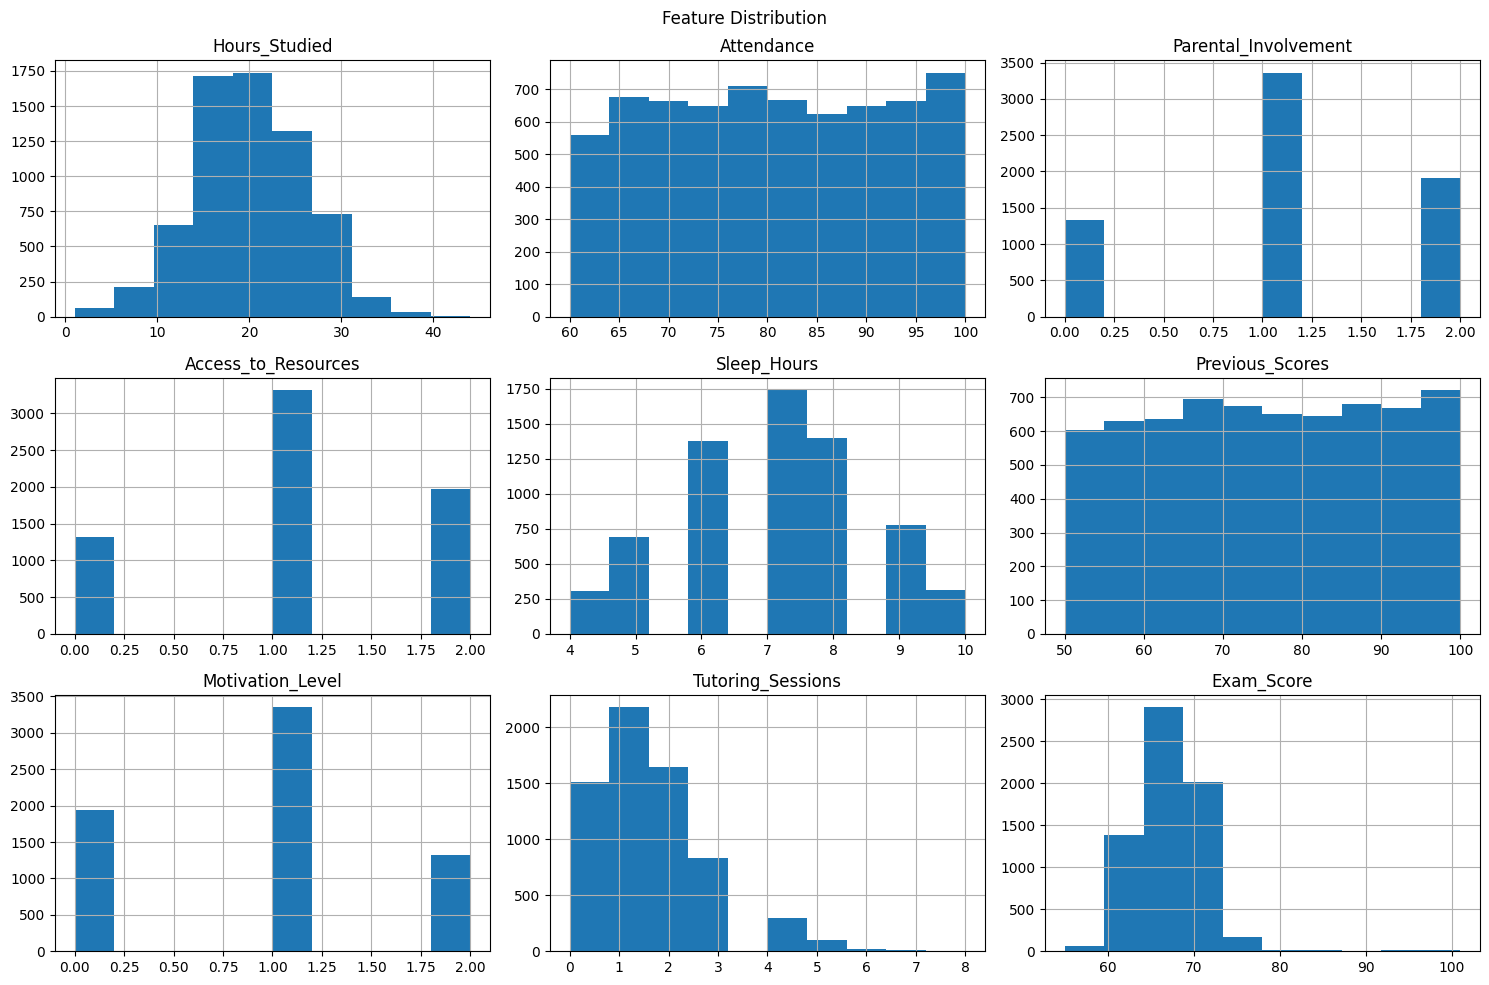

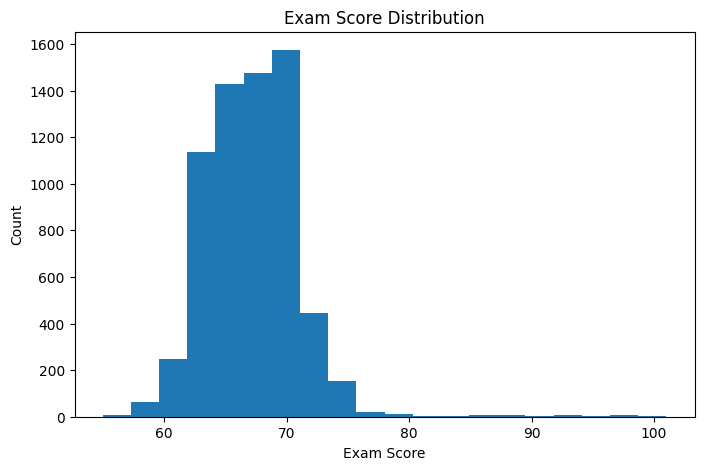


===== CORRELATION WITH EXAM SCORE =====
Exam_Score              1.000000
Attendance              0.581072
Hours_Studied           0.445455
Previous_Scores         0.175079
Access_to_Resources     0.169770
Parental_Involvement    0.157114
Tutoring_Sessions       0.156525
Motivation_Level        0.086937
Sleep_Hours            -0.017022
Name: Exam_Score, dtype: float64


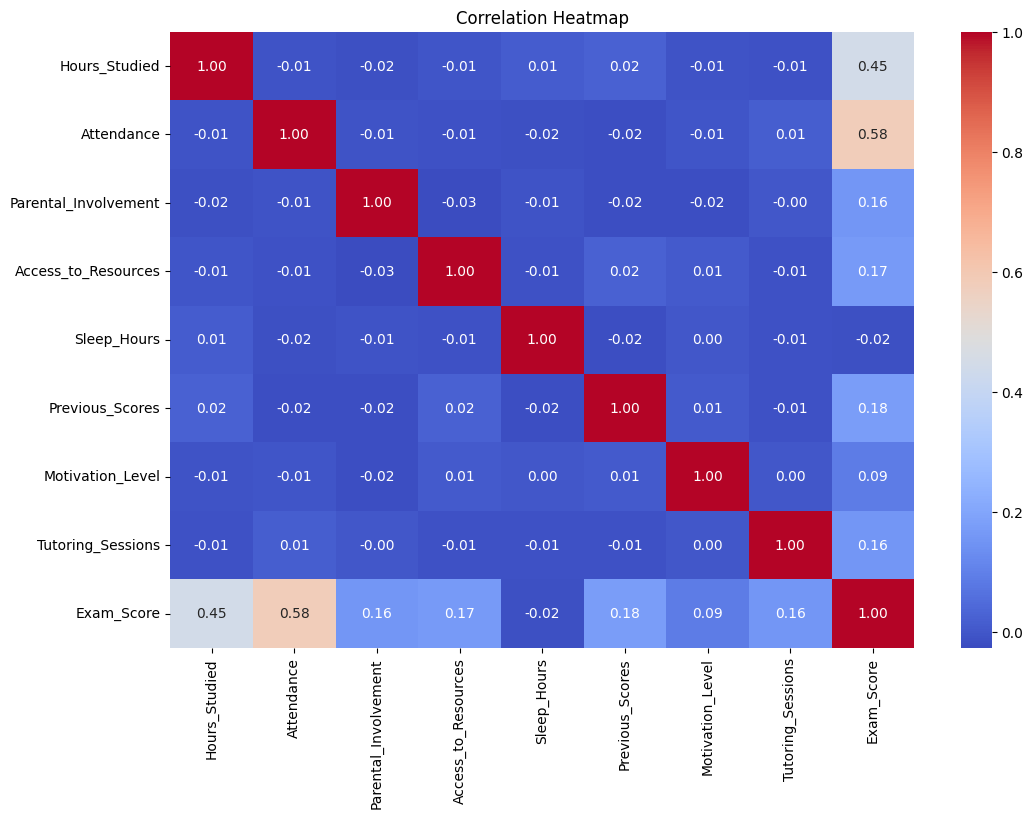

In [29]:
############################################################
# Student Performance Data Analysis
# https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
############################################################

##############################
# 1. IMPORT
##############################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##############################
# 2. DATA LOAD
##############################

df = pd.read_csv(
    "StudentPerformanceFactors_encoded.csv"
)

##############################
# 3. DATA OVERVIEW
##############################

print("===== DATA HEAD =====")
print(df.head())

print("\n===== DATA INFO =====")
print(df.info())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

##############################
# 4. BASIC STATISTICS
##############################

print("\n===== DESCRIBE =====")
print(df.describe())

##############################
# 5. FEATURE DISTRIBUTION
##############################

df.hist(figsize=(15,10))

plt.suptitle("Feature Distribution")

plt.tight_layout()

plt.show()

##############################
# 6. EXAM SCORE DISTRIBUTION
##############################

plt.figure(figsize=(8,5))

plt.hist(
    df["Exam_Score"],
    bins=20
)

plt.xlabel("Exam Score")
plt.ylabel("Count")

plt.title("Exam Score Distribution")

plt.show()

##############################
# 7. CORRELATION ANALYSIS
##############################

corr = df.corr(numeric_only=True)

print("\n===== CORRELATION WITH EXAM SCORE =====")

print(
    corr["Exam_Score"].sort_values(
        ascending=False
    )
)

##############################
# 8. CORRELATION HEATMAP
##############################

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

############################################################
# END
############################################################

In [ ]:
###################################################################
# 학생 위험 예측 시스템
# Decision Tree (ID3) 기반
###################################################################

##############################
# 1. 라이브러리 import
##############################

import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.tree import (
    DecisionTreeClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

##############################
# 2. 데이터 불러오기
##############################

df = pd.read_csv(
    "StudentPerformanceFactors_encoded.csv"
)

##############################
# 3. Train / Test 분리
##############################
# Data Leakage 방지를 위해
# 먼저 데이터를 분리한 후 threshold 계산

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

##############################
# 4. 위험군(risk) 라벨 생성
##############################
# 상위 23% 기준으로 위험군 분류

threshold = train_df["Exam_Score"].quantile(0.77)

train_df["risk"] = (
    train_df["Exam_Score"] < threshold
).astype(int)

test_df["risk"] = (
    test_df["Exam_Score"] < threshold
).astype(int)

##############################
# 5. One-Hot Encoding
##############################
# 범주형 데이터를 숫자 벡터로 변환

categorical_cols = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level"
]

train_df = pd.get_dummies(
    train_df,
    columns=categorical_cols
)

test_df = pd.get_dummies(
    test_df,
    columns=categorical_cols
)

# train / test 컬럼 맞추기
train_df, test_df = train_df.align(
    test_df,
    join="left",
    axis=1,
    fill_value=0
)

##############################
# 6. Feature / Label 분리
##############################

drop_cols = [
    "Exam_Score",
    "risk"
]

X_train = train_df.drop(drop_cols, axis=1)
y_train = train_df["risk"]

X_test = test_df.drop(drop_cols, axis=1)
y_test = test_df["risk"]

##############################
# 7. 최적 Depth 탐색
##############################
# Recall 기준으로 가장 좋은 Depth 탐색

depths = range(1, 21)

cv_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="entropy",   # ID3 방식
        max_depth=depth,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    )

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall"
    )

    cv_scores.append(cv.mean())

##############################
# 8. 최적 Depth 선택
##############################

best_depth = depths[
    cv_scores.index(max(cv_scores))
]

print("===== 최적 Depth =====")
print(best_depth)

##############################
# 9. 최종 모델 생성
##############################

tree_model = DecisionTreeClassifier(
    criterion="entropy",   # ID3
    max_depth=best_depth,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

##############################
# 10. 예측
##############################

y_pred = tree_model.predict(X_test)

##############################
# 11. 모델 성능 출력
##############################

print("\n===== 모델 성능 =====")

print(
    "정확도:",
    accuracy_score(y_test, y_pred)
)

print("\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

##############################
# Confusion Matrix 출력
##############################

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n===== Confusion Matrix =====")

print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTN (정상→정상): {tn}")
print(f"FP (정상→위험): {fp}")
print(f"FN (위험→정상): {fn}")
print(f"TP (위험→위험): {tp}")

##############################
# Feature Importance 출력
##############################

print("\n===== Feature Importance =====")

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

##############################
# 12. 샘플 학생 입력
##############################

sample_student = pd.DataFrame([{
    "Hours_Studied": 27,
    "Attendance": 75,
    "Sleep_Hours": 6,
    "Previous_Scores": 65,
    "Tutoring_Sessions": 1,

    # Parental_Involvement = Medium
    "Parental_Involvement_0": 0,
    "Parental_Involvement_1": 1,
    "Parental_Involvement_2": 0,

    # Access_to_Resources = Medium
    "Access_to_Resources_0": 0,
    "Access_to_Resources_1": 1,
    "Access_to_Resources_2": 0,

    # Motivation_Level = Medium
    "Motivation_Level_0": 0,
    "Motivation_Level_1": 1,
    "Motivation_Level_2": 0
}])

# 컬럼 정렬
sample_student = sample_student.reindex(
    columns=X_train.columns,
    fill_value=0
)

##############################
# 13. 샘플 학생 예측
##############################

prediction = tree_model.predict(
    sample_student
)

print("\n===== 학생 예측 결과 =====")

if prediction[0] == 1:
    print("예측 결과: 위험군 학생")
else:
    print("예측 결과: 안전군 학생")

##############################
# 14. Decision Tree 기반 분석
##############################

print("\n===== 위험 원인 분석 =====")

def explain_decision(sample):

    node_indicator = tree_model.decision_path(sample)

    leaf_id = tree_model.apply(sample)

    feature = tree_model.tree_.feature

    threshold = tree_model.tree_.threshold

    sample_id = 0

    node_index = node_indicator.indices[
        node_indicator.indptr[sample_id]:
        node_indicator.indptr[sample_id + 1]
    ]

    risk_reasons = []

    for node_id in node_index:

        # leaf node
        if leaf_id[sample_id] == node_id:
            continue

        feature_name = X_train.columns[
            feature[node_id]
        ]

        threshold_value = threshold[node_id]

        value = sample.iloc[
            0,
            feature[node_id]
        ]

        # LEFT → 위험 증가
        if value <= threshold_value:

            print(
                f"{feature_name} <= {threshold_value:.2f}"
            )

            print(
                f"현재 값: {value}"
            )

            print(
                "→ 위험도를 증가시키는 조건\n"
            )

            risk_reasons.append(feature_name)

        # RIGHT → 위험 감소
        else:

            print(
                f"{feature_name} > {threshold_value:.2f}"
            )

            print(
                f"현재 값: {value}"
            )

            print(
                "→ 위험도를 감소시키는 조건\n"
            )

    ###############################################################
    # 최종 분석 결과
    ###############################################################

    print("===== 최종 분석 =====\n")

    print("주요 위험 요인:")

    for reason in risk_reasons:

        print(f"- {reason}")

    print("\n개선 방향:")

    if "Attendance" in risk_reasons:

        print("- 출석률 개선 필요")

    if "Hours_Studied" in risk_reasons:

        print("- 공부 시간 증가 필요")

    if "Sleep_Hours" in risk_reasons:

        print("- 수면 습관 개선 필요")

    if "Previous_Scores" in risk_reasons:

        print("- 기초 개념 복습 필요")

    if "Tutoring_Sessions" in risk_reasons:

        print("- 추가 학습 지도 필요")

    for reason in risk_reasons:

        if "Motivation_Level" in reason:

            print("- 학습 동기 향상 필요")

        if "Access_to_Resources" in reason:

            print("- 학습 자료 접근성 개선 필요")

        if "Parental_Involvement" in reason:

            print("- 부모 참여도 향상 필요")

##############################
# 분석 실행
##############################

explain_decision(sample_student)

##################################################################
# END
##################################################################

===== 최적 Depth =====
5

===== 모델 성능 =====
정확도: 0.8608169440242057


              precision    recall  f1-score   support

           0       0.83      0.59      0.69       348
           1       0.87      0.96      0.91       974

    accuracy                           0.86      1322
   macro avg       0.85      0.77      0.80      1322
weighted avg       0.86      0.86      0.85      1322


===== Confusion Matrix =====
[[206 142]
 [ 42 932]]

TN (정상→정상): 206
FP (정상→위험): 142
FN (위험→정상): 42
TP (위험→위험): 932

===== Feature Importance =====
                   Feature  Importance
1               Attendance    0.514323
0            Hours_Studied    0.359011
3          Previous_Scores    0.084617
4        Tutoring_Sessions    0.016324
10   Access_to_Resources_2    0.008495
7   Parental_Involvement_2    0.008426
5   Parental_Involvement_0    0.005425
13      Motivation_Level_2    0.003379
2              Sleep_Hours    0.000000
6   Parental_Involvement_1    0.000000
9    Access_to_Resources_1 